# Nạp thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu

In [2]:
path = 'C:\\Users\\Admin\\Downloads\\Report_Entry_Test\\TCBS_phan_loai_noi_dung.xlsx'
df = pd.read_excel(path)

# EDA

In [3]:
print(df.head())

   Platform     Type                                              Title  \
0      news     post    Quý đầu năm ảm đạm của loạt công ty chứng khoán   
1      news     post  Đằng sau việc ông Phạm Nhật Vượng rót “tiền tấ...   
2      news     post    Quý đầu năm ảm đạm của loạt công ty chứng khoán   
3  facebook  comment                                                NaN   
4  facebook  comment                                                NaN   

                                             Content Created Date Sentiment  \
0  Mùa báo cáo kết quả kinh doanh quý I/2023 tại ...   05/01/2023  negative   
1  https://sputniknews.vn/20230501/dang-sau-viec-...   05/01/2023  positive   
2   Nhóm công ty chứng khoán là bộ phận gắn liền ...   05/01/2023  negative   
3                                Mua dig cũng ok ace   05/01/2023   neutral   
4  Lê Xuân Khánh Phương cái này chuẩn. Nên mảng r...   05/01/2023  negative   

                   Author                                         Author U

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Platform            291 non-null    object
 1   Type                291 non-null    object
 2   Title               135 non-null    object
 3   Content             289 non-null    object
 4   Created Date        291 non-null    object
 5   Sentiment           291 non-null    object
 6   Author              291 non-null    object
 7   Author URL          291 non-null    object
 8   Reaction            291 non-null    int64 
 9   Comments            291 non-null    int64 
 10  Shares              291 non-null    int64 
 11  Like                291 non-null    object
 12  Love                291 non-null    int64 
 13  Haha                291 non-null    int64 
 14  Wow                 291 non-null    int64 
 15  Sad                 291 non-null    int64 
 16  Angry               291 no

In [5]:
print(df.shape)

(291, 19)


In [6]:
print(df.columns)

Index(['Platform', 'Type', 'Title', 'Content', 'Created Date', 'Sentiment',
       'Author', 'Author URL', 'Reaction', 'Comments', 'Shares', 'Like',
       'Love', 'Haha', 'Wow', 'Sad', 'Angry', 'Care', 'phan_loai_noi_dung'],
      dtype='object')


In [7]:
print(df.dtypes)

Platform              object
Type                  object
Title                 object
Content               object
Created Date          object
Sentiment             object
Author                object
Author URL            object
Reaction               int64
Comments               int64
Shares                 int64
Like                  object
Love                   int64
Haha                   int64
Wow                    int64
Sad                    int64
Angry                  int64
Care                   int64
phan_loai_noi_dung    object
dtype: object


# Bảng thống kê tần số 

In [13]:
name_col = ['Platform', 'Type', 'Sentiment', 'Reaction', 'Comments', 'Shares', 'Like', 'Love', 'Haha', 'Wow', 'Sad', 'Angry', 'Care']

In [16]:
for item in name_col:
    print(df[item].value_counts())

Platform
facebook    155
youtube      64
news         44
forum        27
tiktok        1
Name: count, dtype: int64
Type
comment    183
post       108
Name: count, dtype: int64
Sentiment
neutral     170
positive     62
negative     59
Name: count, dtype: int64
Reaction
0      239
1       11
3        8
4        5
2        4
7        3
23       2
67       1
14       1
109      1
28       1
18       1
22       1
19       1
15       1
369      1
43       1
51       1
9        1
83       1
53       1
12       1
91       1
86       1
17       1
30       1
Name: count, dtype: int64
Comments
0     229
1      31
3      12
2       4
4       3
5       2
6       2
43      1
18      1
20      1
89      1
25      1
9       1
14      1
46      1
Name: count, dtype: int64
Shares
0     279
2       3
1       2
10      1
23      1
17      1
16      1
9       1
7       1
3       1
Name: count, dtype: int64
Like
0     272
1       7
4       3
7       2
2       2
83      1
53      1
3       1
86      1
17    

# Xử lý biến Like

In [8]:
print(df['Like'])

0      0
1      0
2      0
3      0
4      1
      ..
286    0
287    0
288    0
289    0
290    0
Name: Like, Length: 291, dtype: object


In [9]:
i = []
for index, item in enumerate(list(df['Like'])):
    if (isinstance(item, str)):
        i += [index]

print(i)

[129, 203, 204, 205, 241, 245, 246, 247, 248, 252, 253]


In [10]:
for item in i:
    print(df['Like'][item], end = ' ')

"7" "83" "7" "53" "4" "4" "2" "3" "4" "86" "17" 

In [11]:
for index, item in enumerate(df['Like']):
    if isinstance(item, str):
        df.loc[index, 'Like'] = int(item.replace('"', ''))

In [46]:
df.to_excel('Clean_data.xlsx', index=False)

# Câu 1: Định nghĩa các trường thông tin của sheet dữ liệu



1. Platform     :           Nền tảng số mà thông tin được đăng tải
2. Type         :           Loại bài viết được ghi nhận (post hoặc comment)
3. Title        :           Tiêu đề của thông tin được đăng tải
4. Content      :           Tóm tắt nội dung của thông tin được đăng tải
5. Created Date :           Ngày - tháng - năm thông tin được đăng tải
6. Sentiment    :           Sắc thái - phản hồi mà bài viết nhận được
7. Author       :           Tác giả của bài viết
8. Author URL   :           path - đường link dẫn đến bài viết
9. Reaction     :           Số lượt xem của bài viết
10. Comments    :           Số lượt bình luận bài viết nhận được
11. Shares      :           Số lượt chia sẻ của bài viết
12. Like        :           Số lượt thích bài viết nhận được
13. Love        :           Số lượt thả tim bài viết nhận được
14. Haha        :           Số lượt thả haha bài viết nhận được
15. Wow         :           Số lượt thả wow bài viết nhận được
16. Sad         :           Số lượt phản hồi buồn sau khi đọc bài viết
17. Angry       :           Số lượt phản hồi tức giận sau khi đọc bài viết
18. Care        :           Số lượt phản hồi quan tâm sau khi đọc bài viết

# Câu 4: Thống kê các chỉ số

In [27]:
cau_4 = df.groupby(['Created Date', 'Type']).size().unstack(fill_value=0)

In [28]:
bang_tam = df.groupby('Created Date')[['Like', 'Shares', 'Comments']].sum()
cau_4['Engagement'] = bang_tam['Like'] + bang_tam['Shares'] + bang_tam['Comments']
print(cau_4)

Type          comment  post Engagement
Created Date                          
05/01/2023          2     6          1
05/02/2023          3     2          0
05/03/2023          6     9         37
05/04/2023          1    10         39
05/05/2023          2     5          2
05/06/2023          0     5         45
05/07/2023          1     7          4
05/08/2023          1     6          3
05/09/2023          3     9         32
05/10/2023          5     1          0
05/11/2023         10     3          3
05/12/2023          1     3          3
05/13/2023          0     1          0
05/14/2023          0     1          3
05/15/2023          3     0          0
05/16/2023         19     3          3
05/17/2023          3     2         10
05/18/2023         18     2        106
05/19/2023         17     0          0
05/20/2023          3     0          0
05/21/2023          0     3          0
05/22/2023          0     5          9
05/23/2023          1     0          0
05/24/2023          6    

# Câu 5: Vẽ biểu đồ xu hướng thảo luận (mention) và tương tác (egagement) theo thời gian. Cho thấy được lượng thảo luận và tương tác mỗi ngày là bao nhiêu.

In [29]:
cau_4['Mention'] = df.groupby('Created Date').size()
print(cau_4)

Type          comment  post Engagement  Mention
Created Date                                   
05/01/2023          2     6          1        8
05/02/2023          3     2          0        5
05/03/2023          6     9         37       15
05/04/2023          1    10         39       11
05/05/2023          2     5          2        7
05/06/2023          0     5         45        5
05/07/2023          1     7          4        8
05/08/2023          1     6          3        7
05/09/2023          3     9         32       12
05/10/2023          5     1          0        6
05/11/2023         10     3          3       13
05/12/2023          1     3          3        4
05/13/2023          0     1          0        1
05/14/2023          0     1          3        1
05/15/2023          3     0          0        3
05/16/2023         19     3          3       22
05/17/2023          3     2         10        5
05/18/2023         18     2        106       20
05/19/2023         17     0          0  

In [25]:
seq = []
for item in range(1, 32, 1):
    if (item != 27):
        seq += [item]
print(seq)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31]


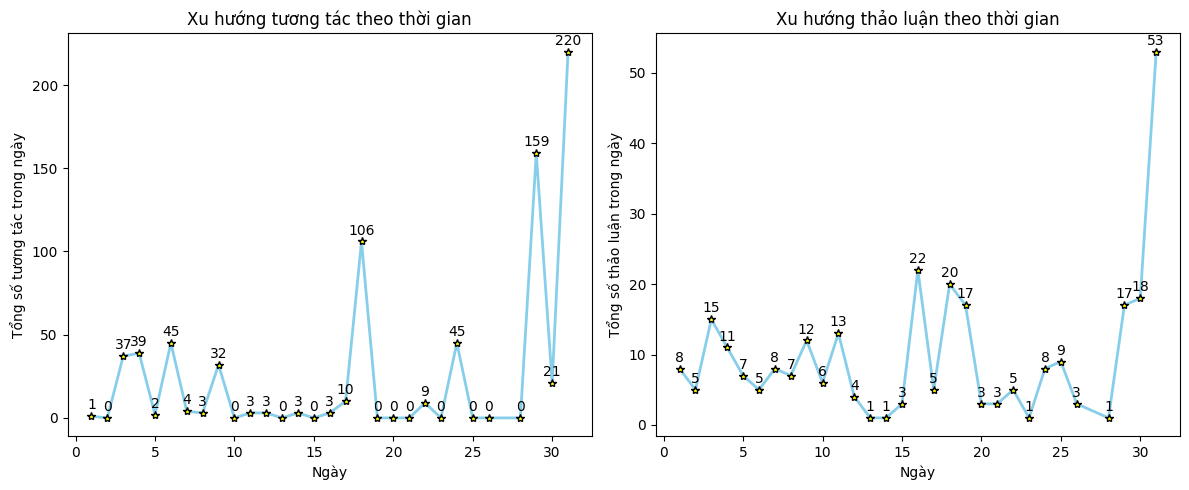

In [34]:
figure, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].plot(seq, cau_4['Engagement'],
             linestyle = 'solid',
             linewidth = 2,
             color = 'skyblue',
             marker = '*',
             markersize = 6,
             markerfacecolor = 'yellow',
             markeredgecolor = 'black')

axes[0].set_title('Xu hướng tương tác theo thời gian')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Tổng số tương tác trong ngày')

for xi, yi in zip(seq, cau_4['Engagement']):
    axes[0].annotate(
        yi,
        (xi, yi),
        textcoords = 'offset points',
        xytext = (0, 5),
        ha = 'center')

axes[1].plot(seq, cau_4['Mention'],
             linestyle = 'solid',
             linewidth = 2,
             color = 'skyblue',
             marker = '*',
             markersize = 6,
             markerfacecolor = 'yellow',
             markeredgecolor = 'black')

axes[1].set_title('Xu hướng thảo luận theo thời gian')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Tổng số thảo luận trong ngày')

for xi, yi in zip(seq, cau_4['Mention']):
    axes[1].annotate(
        yi,
        (xi, yi),
        textcoords = 'offset points',
        xytext = (0, 5),
        ha = 'center')
    
plt.tight_layout()
    
plt.show()

# Câu 6: Vẽ biểu đồ tỷ lệ thảo luận trên từng nền tảng

In [67]:
print(df['Platform'].value_counts())

Platform
facebook    155
youtube      64
news         44
forum        27
tiktok        1
Name: count, dtype: int64


In [68]:
print(df['Type'].value_counts())

Type
comment    183
post       108
Name: count, dtype: int64


In [35]:
table = df.groupby(['Platform', 'Type']).size().unstack(fill_value=0)
table['Total'] = table.sum(axis=1)
table['Per_cmt'] = table['comment'] / table['Total']
table['Per_post'] = table['post'] / table['Total']
print(table)

Type      comment  post  Total   Per_cmt  Per_post
Platform                                          
facebook      132    23    155  0.851613  0.148387
forum           0    27     27  0.000000  1.000000
news            0    44     44  0.000000  1.000000
tiktok          1     0      1  1.000000  0.000000
youtube        50    14     64  0.781250  0.218750


In [50]:
data = {
    'comment': table['Per_cmt'].values,
    'post': table['Per_post'].values
}

frame = pd.DataFrame(data, index = table.index)
print(frame)

           comment      post
Platform                    
facebook  0.851613  0.148387
forum     0.000000  1.000000
news      0.000000  1.000000
tiktok    1.000000  0.000000
youtube   0.781250  0.218750


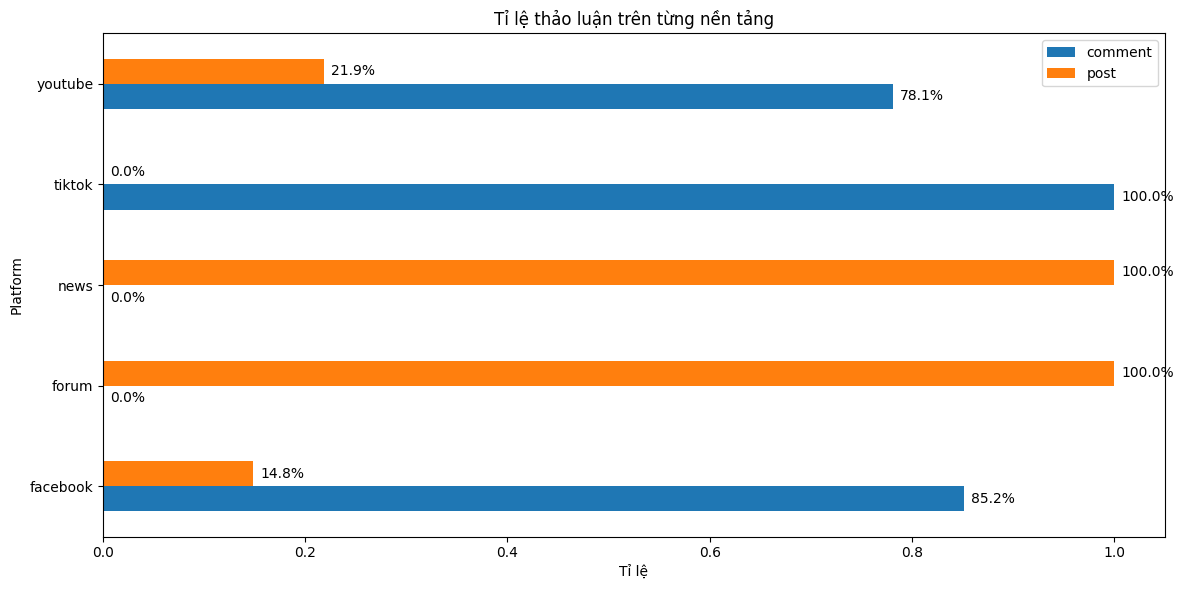

In [57]:
ax = frame.plot(kind='barh', figsize=(12, 6))

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1%}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        xytext=(5, 0),
        textcoords='offset points',
        va='center')
    
plt.xlabel('Tỉ lệ')
plt.title('Tỉ lệ thảo luận trên từng nền tảng')

plt.tight_layout()

plt.show()

# Câu 7: Vẽ biểu đồ thể hiện tỉ lệ sắc thái thảo luận (sentiment)

In [33]:
print(df['Platform'].value_counts())

Platform
facebook    155
youtube      64
news         44
forum        27
tiktok        1
Name: count, dtype: int64


In [35]:
print(df['Sentiment'].value_counts())

Sentiment
neutral     170
positive     62
negative     59
Name: count, dtype: int64


In [58]:
cau_7 = df.groupby(['Platform', 'Sentiment']).size().unstack(fill_value=0)
cau_7['Total'] = cau_7['negative'] + cau_7['neutral'] + cau_7['positive'] 
cau_7['Per_negative'] = cau_7['negative'] / cau_7['Total']
cau_7['Per_neutral'] = cau_7['neutral'] / cau_7['Total']
cau_7['Per_positive'] = cau_7['positive'] / cau_7['Total']
print(cau_7)

Sentiment  negative  neutral  positive  Total  Per_negative  Per_neutral  \
Platform                                                                   
facebook          8      114        33    155      0.051613     0.735484   
forum            18        5         4     27      0.666667     0.185185   
news             27        6        11     44      0.613636     0.136364   
tiktok            0        0         1      1      0.000000     0.000000   
youtube           6       45        13     64      0.093750     0.703125   

Sentiment  Per_positive  
Platform                 
facebook       0.212903  
forum          0.148148  
news           0.250000  
tiktok         1.000000  
youtube        0.203125  


In [59]:
chi_so = cau_7.index
print(chi_so)

Index(['facebook', 'forum', 'news', 'tiktok', 'youtube'], dtype='object', name='Platform')


In [62]:
dict = {
    'Per_negative': cau_7['Per_negative'].values,
    'Per_neutral': cau_7['Per_neutral'].values,
    'Per_positive': cau_7['Per_positive'].values
}

frame_dict = pd.DataFrame(dict, index = chi_so)
print(frame_dict)

          Per_negative  Per_neutral  Per_positive
Platform                                         
facebook      0.051613     0.735484      0.212903
forum         0.666667     0.185185      0.148148
news          0.613636     0.136364      0.250000
tiktok        0.000000     0.000000      1.000000
youtube       0.093750     0.703125      0.203125


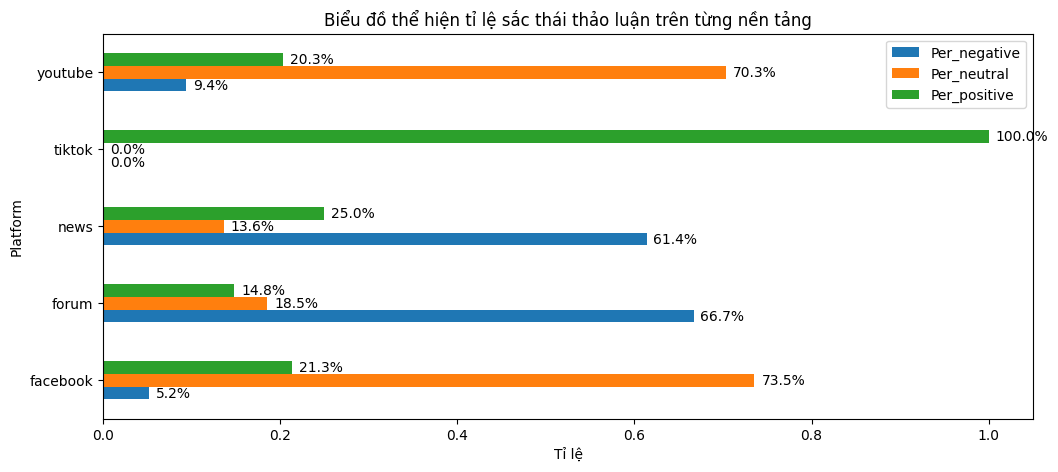

In [69]:
axe = frame_dict.plot(kind = 'barh', figsize=(12,5))

plt.xlabel('Tỉ lệ')
plt.title('Biểu đồ thể hiện tỉ lệ sắc thái thảo luận trên từng nền tảng')

for p in axe.patches:
    axe.annotate(
        f'{p.get_width():.1%}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        xytext=(5, 0),
        textcoords='offset points',
        va='center')


In [ ]:
# Thông tin khác nhận được từ câu hỏi
df_ssub = df.groupby(['Platform', 'Sentiment', 'Type']).size().unstack(fill_value=0)
df_ssub['Total'] = df_ssub['comment'] + df_ssub['post']
df_ssub['Per_cmt'] = df_ssub['comment'] / df_ssub['Total']
df_ssub['Per_post'] = df_ssub['post'] / df_ssub['Total']
print(df_ssub)

Type                comment  post  Total   Per_cmt  Per_post
Platform Sentiment                                          
facebook negative         4     4      8  0.500000  0.500000
         neutral        105     9    114  0.921053  0.078947
         positive        23    10     33  0.696970  0.303030
forum    negative         0    18     18  0.000000  1.000000
         neutral          0     5      5  0.000000  1.000000
         positive         0     4      4  0.000000  1.000000
news     negative         0    27     27  0.000000  1.000000
         neutral          0     6      6  0.000000  1.000000
         positive         0    11     11  0.000000  1.000000
tiktok   positive         1     0      1  1.000000  0.000000
youtube  negative         3     3      6  0.500000  0.500000
         neutral         39     6     45  0.866667  0.133333
         positive         8     5     13  0.615385  0.384615


# Câu 8: Top 5 chủ đề (nội dung) có nhiều thảo luận nhất trong bảng dữ liệu và tỉ lệ phần trăm thảo luận của từng chủ đề (nội dung).

In [ ]:
# top 5 chủ đề (nội dung) có nhiều thảo luận nhất trong bảng dữ liệu
top_5 = df.sort_values(by = 'Comments', ascending=False).head()[['Title', 'Content']]
print(top_5)

                                                 Title  \
135                                                NaN   
252  Chứng khoán hôm nay | Nhận định thị trường: VN...   
47      Ngôi nhà nhỏ trên Thảo Nguyên - P31 | Page 126   
182                                                NaN   
25                                                 NaN   

                                               Content  
135  ? TCBS áp dụng Zero Fee miễn phí giao dịch cho...  
252  ✅ Chứng khoán hôm nay | Nhận định thị trường: ...  
47   Win_2017 đã viết: ↑ Xem tất cả A thằng cu em ,...  
182  https://www.tcbs.com.vn/documents/10181/0/Thay...  
25   ? MIỄN PHÍ MỞ TÀI KHOẢN SỐ ĐẸP ♦️ MIỄN PHÍ GIA...  


In [ ]:
# tỉ lệ phần trăm thảo luận của từng chủ đề
total = df['Comments'].sum()

ti_le = df['Comments'].sort_values(ascending = False).head() / total
print(ti_le)

135    0.238606
252    0.123324
47     0.115282
182    0.067024
25     0.053619
Name: Comments, dtype: float64
